<a href="https://colab.research.google.com/github/Abel-Kurian/Ai-internship/blob/main/Day5_Brain_tumor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Brain Tumor Image Classification using Scikit-learn (Conceptual Example)**

This notebook demonstrates a conceptual workflow for classifying images (e.g., brain MRI scans) as having a tumor or not, using `sklearn`. Since actual image data isn't available, we'll simulate the process with synthetic data.

**Outline:**
1.  Simulate Image Data (features and labels).
2.  Preprocess and Flatten (if necessary, though simulated data will be ready).
3.  Split Data into Training and Testing sets.
4.  Train a `LogisticRegression` classifier.
5.  Evaluate the model's performance.

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Simulate Image Data ---
# In a real scenario, you would load and preprocess actual image data.
# For this example, let's simulate 1000 'images', each represented by 64 features (e.g., flattened 8x8 pixels).
# We'll create two classes: 0 (no tumor) and 1 (tumor).

num_samples = 1000
num_features = 64 # Represents a flattened image (e.g., 8x8 pixels)

# Simulate features: Random data for simplicity
X = np.random.rand(num_samples, num_features)

# Simulate labels: Roughly half with tumors, half without, but with some noise
# Let's make the tumor class (1) slightly dependent on some features
y = np.zeros(num_samples, dtype=int)

# Introduce a pattern for 'tumor' cases: if sum of first few features is high
y[(X[:, :5].sum(axis=1) > 2.5)] = 1

# Adjust to get roughly 50/50 split or introduce more noise
# This is just for demonstration, real data would have clearer patterns
num_tumors = np.sum(y == 1)
num_no_tumors = np.sum(y == 0)

# If one class is too dominant, balance it a bit for the demo
if num_tumors < num_samples / 4 or num_no_tumors < num_samples / 4:
    # Resample or adjust to make a more balanced synthetic dataset for classification demo
    tumor_indices = np.where(X[:, :5].sum(axis=1) > 2.0)[0]
    non_tumor_indices = np.where(X[:, :5].sum(axis=1) <= 2.0)[0]

    # Ensure roughly equal classes for a better classification demo
    balanced_indices = np.concatenate([
        np.random.choice(tumor_indices, min(len(tumor_indices), num_samples // 2), replace=False),
        np.random.choice(non_tumor_indices, min(len(non_tumor_indices), num_samples // 2), replace=False)
    ])

    X = X[balanced_indices]
    y = y[balanced_indices]

print(f"Simulated dataset created: {X.shape[0]} samples, {X.shape[1]} features.")
print(f"Labels distribution: {np.sum(y == 0)} 'No Tumor', {np.sum(y == 1)} 'Tumor'.")

Simulated dataset created: 1000 samples, 64 features.
Labels distribution: 486 'No Tumor', 514 'Tumor'.


### **2. Data Splitting (Real Data)**

We'll split the actual image data (`X_real`, `y_real`) into training and testing sets to evaluate the model's performance on unseen data.

In [ ]:
# --- 2. Split Data (using real data) ---
X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(X_real, y_real, test_size=0.2, random_state=42, stratify=y_real)

print(f"Training data shape: {X_train_real.shape}")
print(f"Testing data shape: {X_test_real.shape}")
print(f"Training labels distribution: {np.sum(y_train_real == 0)} 'No Tumor', {np.sum(y_train_real == 1)} 'Tumor'.")
print(f"Testing labels distribution: {np.sum(y_test_real == 0)} 'No Tumor', {np.sum(y_test_real == 1)} 'Tumor'.")

Training data shape: (202, 16384)
Testing data shape: (51, 16384)
Training labels distribution: 78 'No Tumor', 124 'Tumor'.
Testing labels distribution: 20 'No Tumor', 31 'Tumor'.


### **3. Train a Classifier (with Real Data)**

Now, we'll train the `LogisticRegression` model using the actual preprocessed image data.

In [ ]:
# --- 3. Train a Classifier (with real data) ---
model_real = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000) # Increased max_iter for convergence with larger dataset
model_real.fit(X_train_real, y_train_real)

print("Model training complete with real data.")

Model training complete with real data.


### **4. Evaluate the Model (with Real Data)**

Finally, let's evaluate our trained model on the real test set.


Classification Report (Real Data):
              precision    recall  f1-score   support

           0       0.79      0.75      0.77        20
           1       0.84      0.87      0.86        31

    accuracy                           0.82        51
   macro avg       0.82      0.81      0.81        51
weighted avg       0.82      0.82      0.82        51


Confusion Matrix (Real Data):
[[15  5]
 [ 4 27]]


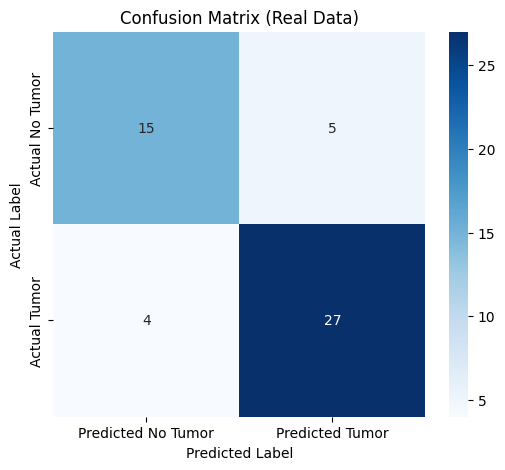

In [ ]:
# --- 4. Evaluate the Model (with real data) ---
y_pred_real = model_real.predict(X_test_real)

print("\nClassification Report (Real Data):")
print(classification_report(y_test_real, y_pred_real))

print("\nConfusion Matrix (Real Data):")
cm_real = confusion_matrix(y_test_real, y_pred_real)
print(cm_real)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_real, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Tumor', 'Predicted Tumor'],
            yticklabels=['Actual No Tumor', 'Actual Tumor'])
plt.title('Confusion Matrix (Real Data)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### **5. Train and Evaluate with Random Forest Classifier**

Let's try a more robust model, the Random Forest Classifier, which is an ensemble learning method that can often improve accuracy and reduce overfitting compared to a simpler model like Logistic Regression.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# --- 5. Train a Random Forest Classifier (with real data) ---
# Instantiate the Random Forest Classifier
# n_estimators: number of trees in the forest
# random_state: for reproducibility
# Adjust parameters like max_depth, min_samples_leaf, etc. for tuning
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores

# Train the model
print("Training Random Forest Classifier...")
model_rf.fit(X_train_real, y_train_real)

print("Random Forest Classifier training complete with real data.")

Training Random Forest Classifier...
Random Forest Classifier training complete with real data.


### **6. Evaluate the Random Forest Model**

Now, let's evaluate the performance of our Random Forest model on the test set.


Classification Report (Random Forest - Real Data):
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.88      0.94      0.91        31

    accuracy                           0.88        51
   macro avg       0.88      0.87      0.87        51
weighted avg       0.88      0.88      0.88        51


Confusion Matrix (Random Forest - Real Data):
[[16  4]
 [ 2 29]]


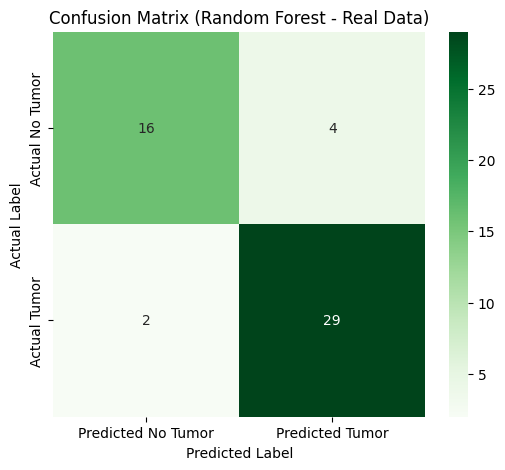

In [ ]:
# --- 6. Evaluate the Random Forest Model (with real data) ---
y_pred_rf = model_rf.predict(X_test_real)

print("\nClassification Report (Random Forest - Real Data):")
print(classification_report(y_test_real, y_pred_rf))

print("\nConfusion Matrix (Random Forest - Real Data):")
cm_rf = confusion_matrix(y_test_real, y_pred_rf)
print(cm_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No Tumor', 'Predicted Tumor'],
            yticklabels=['Actual No Tumor', 'Actual Tumor'])
plt.title('Confusion Matrix (Random Forest - Real Data)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### **7. Train and Evaluate with Support Vector Machine (SVM)**

Let's now train a Support Vector Machine (SVM) classifier, another powerful model known for its effectiveness in high-dimensional spaces.

In [ ]:
from sklearn.svm import SVC

# --- 7. Train an SVM Classifier (with real data) ---
# Instantiate the SVC Classifier
# Using 'rbf' kernel with 'scale' gamma is a common good starting point.
# Increased max_iter for convergence with larger dataset
model_svm = SVC(kernel='rbf', gamma='scale', random_state=42, max_iter=2000)

# Train the model
print("Training Support Vector Machine Classifier...")
model_svm.fit(X_train_real, y_train_real)

print("Support Vector Machine Classifier training complete with real data.")

Training Support Vector Machine Classifier...
Support Vector Machine Classifier training complete with real data.


### **8. Evaluate the SVM Model**

Now, let's evaluate the performance of our SVM model on the test set.


Classification Report (SVM - Real Data):
              precision    recall  f1-score   support

           0       0.93      0.65      0.76        20
           1       0.81      0.97      0.88        31

    accuracy                           0.84        51
   macro avg       0.87      0.81      0.82        51
weighted avg       0.86      0.84      0.84        51


Confusion Matrix (SVM - Real Data):
[[13  7]
 [ 1 30]]


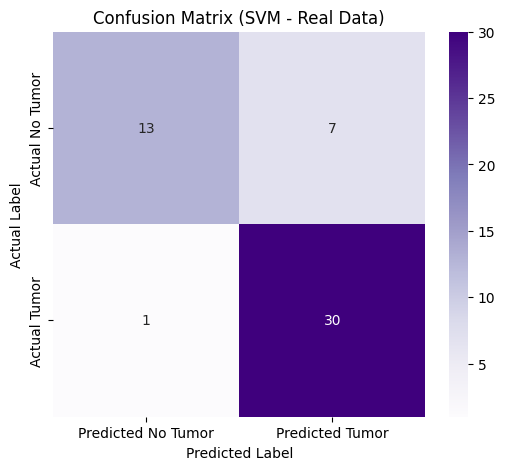

In [ ]:
# --- 8. Evaluate the SVM Model (with real data) ---
y_pred_svm = model_svm.predict(X_test_real)

print("\nClassification Report (SVM - Real Data):")
print(classification_report(y_test_real, y_pred_svm))

print("\nConfusion Matrix (SVM - Real Data):")
cm_svm = confusion_matrix(y_test_real, y_pred_svm)
print(cm_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted No Tumor', 'Predicted Tumor'],
            yticklabels=['Actual No Tumor', 'Actual Tumor'])
plt.title('Confusion Matrix (SVM - Real Data)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

### **9. Compare Model Accuracies**

Let's create a bar plot to visually compare the accuracy of the Logistic Regression, Random Forest, and SVM models.

/tmp/ipykernel_5850/3523025306.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')


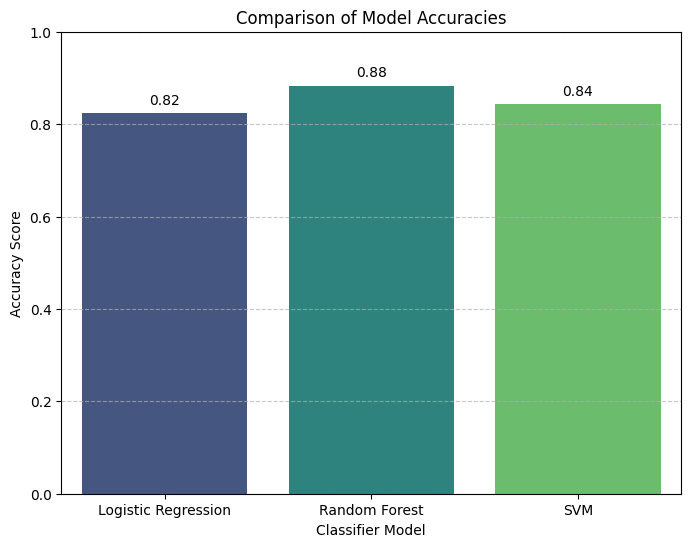

In [ ]:
from sklearn.metrics import accuracy_score

# Calculate accuracies for each model
accuracy_lr = accuracy_score(y_test_real, y_pred_real)
accuracy_rf = accuracy_score(y_test_real, y_pred_rf)
accuracy_svm = accuracy_score(y_test_real, y_pred_svm)

# Create a DataFrame to hold accuracies for plotting
model_accuracies = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_svm]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=model_accuracies, palette='viridis')
plt.title('Comparison of Model Accuracies')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.ylabel('Accuracy Score')
plt.xlabel('Classifier Model')

# Add accuracy values on top of the bars
for index, row in model_accuracies.iterrows():
    plt.text(row.name, row.Accuracy + 0.02, f'{row.Accuracy:.2f}', color='black', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **10. Evaluate Models on a New External Test Dataset**

Now, let's load and preprocess the new test data from `archive (1).zip` and evaluate how our trained models perform on this unseen external dataset.

In [ ]:
import zipfile
import os

new_zip_file_path = '/content/archive (1).zip'
new_extraction_path = '/content/external_test_dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(new_extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(new_zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(new_extraction_path)

print(f"'{new_zip_file_path}' extracted to '{new_extraction_path}'")

# List contents of the extracted directory (optional)
# for root, dirs, files in os.walk(new_extraction_path):
#     level = root.replace(new_extraction_path, '').count(os.sep)
#     indent = ' ' * 4 * (level)
#     print(f'{indent}{os.path.basename(root)}/')
#     subindent = ' ' * 4 * (level + 1)
#     for f in files:
#         print(f'{subindent}{f}')

'/content/archive (1).zip' extracted to '/content/external_test_dataset'


In [ ]:
from PIL import Image
import numpy as np
import os

# Reuse image_size from previous preprocessing
# image_size = (128, 128) # Already defined

X_external_test = [] # To store image features for new test set
y_external_test = [] # To store labels for new test set

print("Loading and preprocessing external test images...")

# Determine the actual root directory inside the extracted folder
# It's common for zip files to contain a single top-level directory
initial_data_root = new_extraction_path

# First, check for a single top-level folder (e.g., 'Brain-Tumor-Classification-DataSet-master')
sub_dirs_level1 = [d for d in os.listdir(initial_data_root) if os.path.isdir(os.path.join(initial_data_root, d))]
if len(sub_dirs_level1) == 1:
    actual_data_root = os.path.join(initial_data_root, sub_dirs_level1[0])
else:
    actual_data_root = initial_data_root # Assume categories are directly in the initial_data_root

# Now, check for a 'Testing' or 'test' subfolder within the current actual_data_root
# This handles cases like 'Brain-Tumor-Classification-DataSet-master/Testing/no_tumor'
sub_dirs_level2 = [d for d in os.listdir(actual_data_root) if os.path.isdir(os.path.join(actual_data_root, d))]
if 'Testing' in sub_dirs_level2:
    actual_data_root = os.path.join(actual_data_root, 'Testing')
elif 'test' in sub_dirs_level2:
    actual_data_root = os.path.join(actual_data_root, 'test')
elif 'Test' in sub_dirs_level2:
    actual_data_root = os.path.join(actual_data_root, 'Test')

print(f"Searching for image categories in: {actual_data_root}")

# Define the mapping for the external dataset's folder structure
# 'no_tumor' maps to 0, other tumor types map to 1
external_data_label_map = {
    'no_tumor': 0,
    'meningioma_tumor': 1,
    'glioma_tumor': 1,
    'pituitary_tumor': 1
}

# Iterate through the actual subdirectories found in actual_data_root
for folder_name in os.listdir(actual_data_root):
    if folder_name in external_data_label_map:
        label = external_data_label_map[folder_name]
        category_path = os.path.join(actual_data_root, folder_name)

        for img_name in os.listdir(category_path):
            if not img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')):
                continue

            img_path = os.path.join(category_path, img_name)
            try:
                img = Image.open(img_path).convert('L') # 'L' for grayscale
                img = img.resize(image_size)
                img_array = np.array(img).flatten() # Flatten to 1D array

                X_external_test.append(img_array)
                y_external_test.append(label)
            except Exception as e:
                print(f"Error loading external image {img_path}: {e}")
    else:
        print(f"Warning: Unexpected folder '{folder_name}' in external dataset. Skipping.")

X_external_test = np.array(X_external_test) / 255.0 # Normalize pixel values
y_external_test = np.array(y_external_test)

print(f"Finished loading {len(X_external_test)} external test images.")
print(f"Shape of external test features (X_external_test): {X_external_test.shape}")
print(f"Shape of external test labels (y_external_test): {y_external_test.shape}")

# Display label distribution for external test set
num_no_tumor_external = np.sum(y_external_test == 0)
num_tumor_external = np.sum(y_external_test == 1)
print(f"External test labels distribution: {num_no_tumor_external} 'No Tumor', {num_tumor_external} 'Tumor'.")

Loading and preprocessing external test images...
Searching for image categories in: /content/external_test_dataset/Brain-Tumor-Classification-DataSet-master/Testing
Finished loading 394 external test images.
Shape of external test features (X_external_test): (394, 16384)
Shape of external test labels (y_external_test): (394,)
External test labels distribution: 105 'No Tumor', 289 'Tumor'.


#### **10.1. Evaluate Logistic Regression on External Test Data**


Classification Report (Logistic Regression - External Test Data):
              precision    recall  f1-score   support

           0       0.44      0.56      0.49       105
           1       0.82      0.74      0.78       289

    accuracy                           0.69       394
   macro avg       0.63      0.65      0.63       394
weighted avg       0.72      0.69      0.70       394


Confusion Matrix (Logistic Regression - External Test Data):
[[ 59  46]
 [ 76 213]]


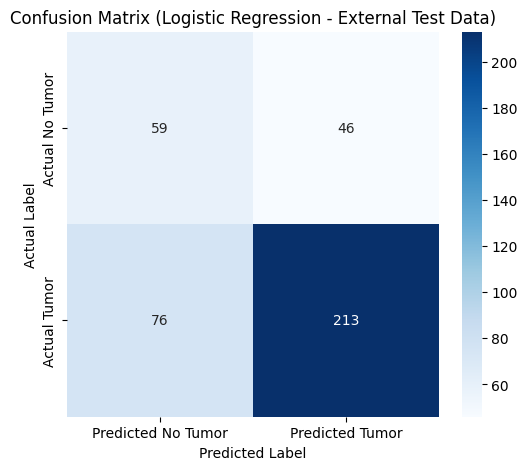

In [ ]:
if X_external_test.shape[0] > 0:
    y_pred_external_lr = model_real.predict(X_external_test)

    print("\nClassification Report (Logistic Regression - External Test Data):")
    print(classification_report(y_external_test, y_pred_external_lr))

    print("\nConfusion Matrix (Logistic Regression - External Test Data):")
    cm_external_lr = confusion_matrix(y_external_test, y_pred_external_lr)
    print(cm_external_lr)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_external_lr, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted No Tumor', 'Predicted Tumor'],
                yticklabels=['Actual No Tumor', 'Actual Tumor'])
    plt.title('Confusion Matrix (Logistic Regression - External Test Data)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
else:
    print("No external test data loaded for Logistic Regression evaluation.")
    y_pred_external_lr = np.array([]) # Define as empty array to prevent NameError in subsequent cells

#### **10.2. Evaluate Random Forest on External Test Data**


Classification Report (Random Forest - External Test Data):
              precision    recall  f1-score   support

           0       0.48      0.62      0.54       105
           1       0.85      0.76      0.80       289

    accuracy                           0.72       394
   macro avg       0.66      0.69      0.67       394
weighted avg       0.75      0.72      0.73       394


Confusion Matrix (Random Forest - External Test Data):
[[ 65  40]
 [ 70 219]]


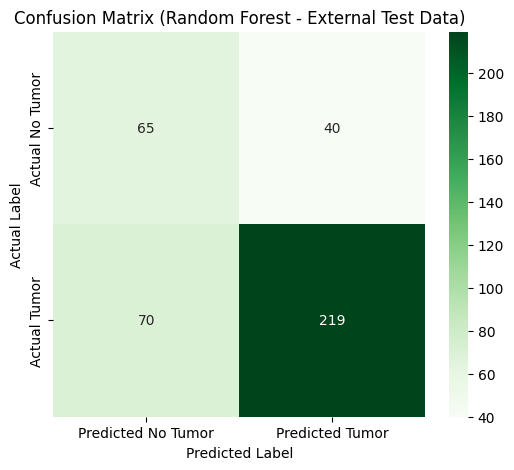

In [ ]:
if X_external_test.shape[0] > 0:
    y_pred_external_rf = model_rf.predict(X_external_test)

    print("\nClassification Report (Random Forest - External Test Data):")
    print(classification_report(y_external_test, y_pred_external_rf))

    print("\nConfusion Matrix (Random Forest - External Test Data):")
    cm_external_rf = confusion_matrix(y_external_test, y_pred_external_rf)
    print(cm_external_rf)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_external_rf, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Predicted No Tumor', 'Predicted Tumor'],
                yticklabels=['Actual No Tumor', 'Actual Tumor'])
    plt.title('Confusion Matrix (Random Forest - External Test Data)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
else:
    print("No external test data loaded for Random Forest evaluation.")
    y_pred_external_rf = np.array([]) # Define as empty array to prevent NameError in subsequent cells

#### **10.3. Evaluate SVM on External Test Data**


Classification Report (SVM - External Test Data):
              precision    recall  f1-score   support

           0       0.46      0.49      0.47       105
           1       0.81      0.80      0.80       289

    accuracy                           0.71       394
   macro avg       0.64      0.64      0.64       394
weighted avg       0.72      0.71      0.72       394


Confusion Matrix (SVM - External Test Data):
[[ 51  54]
 [ 59 230]]


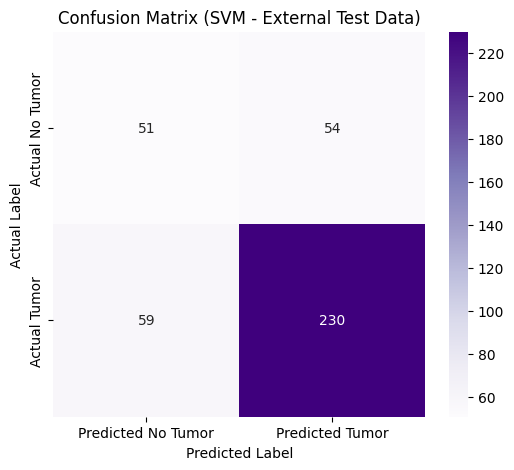

In [ ]:
if X_external_test.shape[0] > 0:
    y_pred_external_svm = model_svm.predict(X_external_test)

    print("\nClassification Report (SVM - External Test Data):")
    print(classification_report(y_external_test, y_pred_external_svm))

    print("\nConfusion Matrix (SVM - External Test Data):")
    cm_external_svm = confusion_matrix(y_external_test, y_pred_external_svm)
    print(cm_external_svm)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_external_svm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Predicted No Tumor', 'Predicted Tumor'],
                yticklabels=['Actual No Tumor', 'Actual Tumor'])
    plt.title('Confusion Matrix (SVM - External Test Data)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
else:
    print("No external test data loaded for SVM evaluation.")
    y_pred_external_svm = np.array([]) # Define as empty array to prevent NameError in subsequent cells

#### **10.4. Compare Model Accuracies on External Test Data**

/tmp/ipykernel_5850/1541792468.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=model_accuracies_external, palette='viridis')


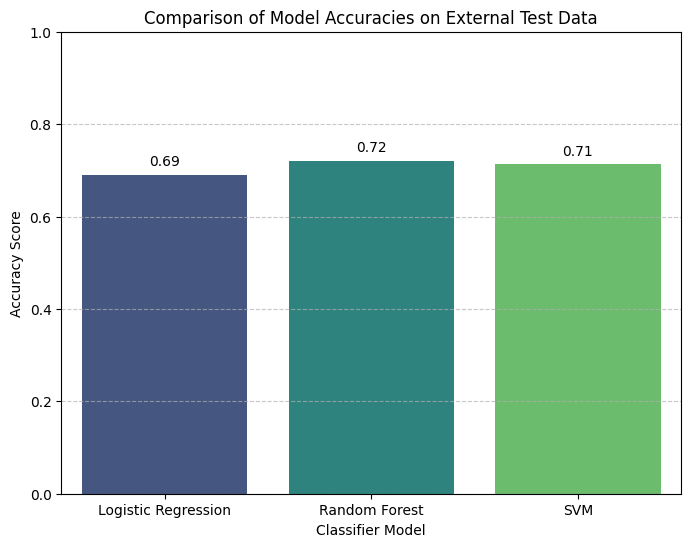

In [ ]:
from sklearn.metrics import accuracy_score

if X_external_test.shape[0] > 0:
    accuracy_external_lr = accuracy_score(y_external_test, y_pred_external_lr)
    accuracy_external_rf = accuracy_score(y_external_test, y_pred_external_rf)
    accuracy_external_svm = accuracy_score(y_external_test, y_pred_external_svm)

    model_accuracies_external = pd.DataFrame({
        'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
        'Accuracy': [accuracy_external_lr, accuracy_external_rf, accuracy_external_svm]
    })

    plt.figure(figsize=(8, 6))
    sns.barplot(x='Model', y='Accuracy', data=model_accuracies_external, palette='viridis')
    plt.title('Comparison of Model Accuracies on External Test Data')
    plt.ylim(0, 1) # Accuracy is between 0 and 1
    plt.ylabel('Accuracy Score')
    plt.xlabel('Classifier Model')

    for index, row in model_accuracies_external.iterrows():
        plt.text(row.name, row.Accuracy + 0.02, f'{row.Accuracy:.2f}', color='black', ha='center')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Cannot compare model accuracies as no external test data was loaded.")

### **11. Merge External and Original Datasets for Retraining**

To improve model generalization, we will combine the initial real dataset (`X_real`, `y_real`) with the external test dataset (`X_external_test`, `y_external_test`). This larger dataset will then be split into new training and testing sets for retraining the models.

In [ ]:
# Combine the original real dataset and the external test dataset
# Ensure both datasets have the same number of features (flattened image size)
if X_real.shape[1] != X_external_test.shape[1]:
    raise ValueError("Feature dimensions of X_real and X_external_test do not match.")

X_combined = np.vstack((X_real, X_external_test))
y_combined = np.concatenate((y_real, y_external_test))

print(f"Combined dataset created: {X_combined.shape[0]} samples, {X_combined.shape[1]} features.")
print(f"Combined labels distribution: {np.sum(y_combined == 0)} 'No Tumor', {np.sum(y_combined == 1)} 'Tumor'.")

Combined dataset created: 647 samples, 16384 features.
Combined labels distribution: 203 'No Tumor', 444 'Tumor'.


### **12. Split Combined Data into New Training and Testing Sets**

In [ ]:
# Split the combined data into new training and testing sets
# We'll use stratify=y_combined to maintain the class distribution in both sets
X_train_combined, X_test_combined, y_train_combined, y_test_combined = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=42, stratify=y_combined
)

print(f"New training data shape: {X_train_combined.shape}")
print(f"New testing data shape: {X_test_combined.shape}")
print(f"New training labels distribution: {np.sum(y_train_combined == 0)} 'No Tumor', {np.sum(y_train_combined == 1)} 'Tumor'.")
print(f"New testing labels distribution: {np.sum(y_test_combined == 0)} 'No Tumor', {np.sum(y_test_combined == 1)} 'Tumor'.")

New training data shape: (517, 16384)
New testing data shape: (130, 16384)
New training labels distribution: 162 'No Tumor', 355 'Tumor'.
New testing labels distribution: 41 'No Tumor', 89 'Tumor'.


### **13. Retrain Models on Combined Dataset**

We will now retrain the Logistic Regression, Random Forest, and SVM models using the newly created combined training dataset (`X_train_combined`, `y_train_combined`).

#### **13.1. Retrain Logistic Regression**

In [ ]:
print("Retraining Logistic Regression model on combined data...")
model_real_combined = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
model_real_combined.fit(X_train_combined, y_train_combined)
print("Logistic Regression retraining complete.")

Retraining Logistic Regression model on combined data...
Logistic Regression retraining complete.


#### **13.2. Retrain Random Forest**

In [ ]:
print("Retraining Random Forest Classifier on combined data...")
model_rf_combined = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_combined.fit(X_train_combined, y_train_combined)
print("Random Forest retraining complete.")

Retraining Random Forest Classifier on combined data...
Random Forest retraining complete.


#### **13.3. Retrain SVM**

In [ ]:
print("Retraining Support Vector Machine Classifier on combined data...")
model_svm_combined = SVC(kernel='rbf', gamma='scale', random_state=42, max_iter=2000)
model_svm_combined.fit(X_train_combined, y_train_combined)
print("SVM retraining complete.")

Retraining Support Vector Machine Classifier on combined data...
SVM retraining complete.


### **14. Evaluate Retrained Models on New Test Set**

Now, let's evaluate the performance of the retrained models on the new test set (`X_test_combined`, `y_test_combined`).

#### **14.1. Evaluate Retrained Logistic Regression**


Classification Report (Retrained Logistic Regression - Combined Test Data):
              precision    recall  f1-score   support

           0       0.78      0.68      0.73        41
           1       0.86      0.91      0.89        89

    accuracy                           0.84       130
   macro avg       0.82      0.80      0.81       130
weighted avg       0.84      0.84      0.84       130


Confusion Matrix (Retrained Logistic Regression - Combined Test Data):
[[28 13]
 [ 8 81]]


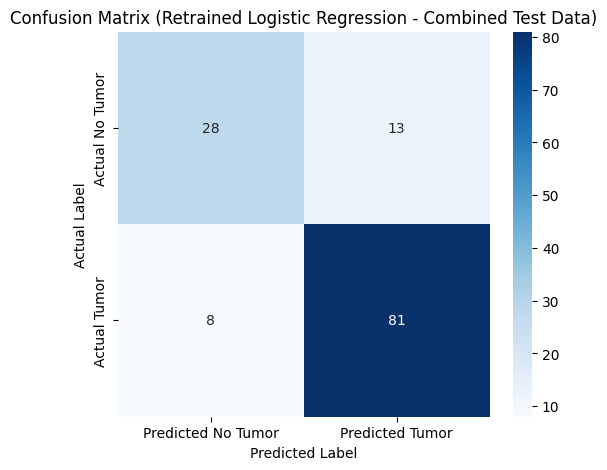

In [ ]:
y_pred_lr_combined = model_real_combined.predict(X_test_combined)

print("\nClassification Report (Retrained Logistic Regression - Combined Test Data):")
print(classification_report(y_test_combined, y_pred_lr_combined))

print("\nConfusion Matrix (Retrained Logistic Regression - Combined Test Data):")
cm_lr_combined = confusion_matrix(y_test_combined, y_pred_lr_combined)
print(cm_lr_combined)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr_combined, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Tumor', 'Predicted Tumor'],
            yticklabels=['Actual No Tumor', 'Actual Tumor'])
plt.title('Confusion Matrix (Retrained Logistic Regression - Combined Test Data)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

#### **14.2. Evaluate Retrained Random Forest**


Classification Report (Retrained Random Forest - Combined Test Data):
              precision    recall  f1-score   support

           0       0.85      0.71      0.77        41
           1       0.88      0.94      0.91        89

    accuracy                           0.87       130
   macro avg       0.86      0.83      0.84       130
weighted avg       0.87      0.87      0.87       130


Confusion Matrix (Retrained Random Forest - Combined Test Data):
[[29 12]
 [ 5 84]]


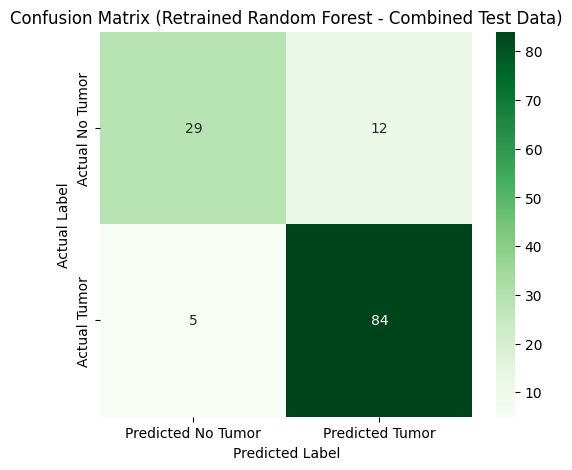

In [ ]:
y_pred_rf_combined = model_rf_combined.predict(X_test_combined)

print("\nClassification Report (Retrained Random Forest - Combined Test Data):")
print(classification_report(y_test_combined, y_pred_rf_combined))

print("\nConfusion Matrix (Retrained Random Forest - Combined Test Data):")
cm_rf_combined = confusion_matrix(y_test_combined, y_pred_rf_combined)
print(cm_rf_combined)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf_combined, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted No Tumor', 'Predicted Tumor'],
            yticklabels=['Actual No Tumor', 'Actual Tumor'])
plt.title('Confusion Matrix (Retrained Random Forest - Combined Test Data)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

#### **14.3. Evaluate Retrained SVM**


Classification Report (Retrained SVM - Combined Test Data):
              precision    recall  f1-score   support

           0       0.75      0.51      0.61        41
           1       0.80      0.92      0.86        89

    accuracy                           0.79       130
   macro avg       0.78      0.72      0.73       130
weighted avg       0.79      0.79      0.78       130


Confusion Matrix (Retrained SVM - Combined Test Data):
[[21 20]
 [ 7 82]]


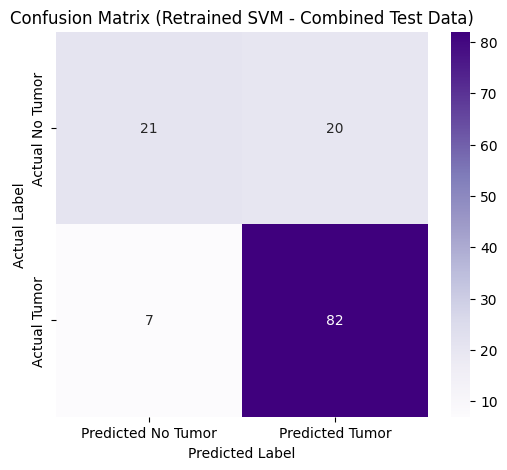

In [ ]:
y_pred_svm_combined = model_svm_combined.predict(X_test_combined)

print("\nClassification Report (Retrained SVM - Combined Test Data):")
print(classification_report(y_test_combined, y_pred_svm_combined))

print("\nConfusion Matrix (Retrained SVM - Combined Test Data):")
cm_svm_combined = confusion_matrix(y_test_combined, y_pred_svm_combined)
print(cm_svm_combined)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm_combined, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted No Tumor', 'Predicted Tumor'],
            yticklabels=['Actual No Tumor', 'Actual Tumor'])
plt.title('Confusion Matrix (Retrained SVM - Combined Test Data)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

#### **14.4. Compare Retrained Model Accuracies**

/tmp/ipykernel_5850/176396969.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=model_accuracies_combined, palette='viridis')


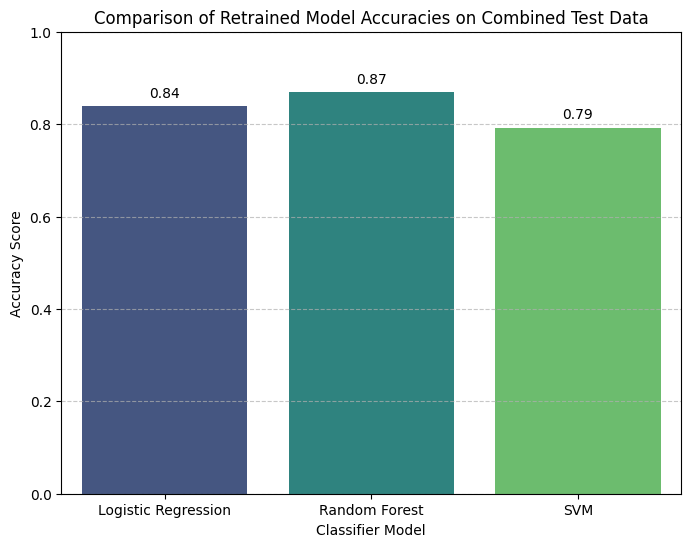

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_lr_combined = accuracy_score(y_test_combined, y_pred_lr_combined)
accuracy_rf_combined = accuracy_score(y_test_combined, y_pred_rf_combined)
accuracy_svm_combined = accuracy_score(y_test_combined, y_pred_svm_combined)

model_accuracies_combined = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [accuracy_lr_combined, accuracy_rf_combined, accuracy_svm_combined]
})

plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=model_accuracies_combined, palette='viridis')
plt.title('Comparison of Retrained Model Accuracies on Combined Test Data')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.ylabel('Accuracy Score')
plt.xlabel('Classifier Model')

for index, row in model_accuracies_combined.iterrows():
    plt.text(row.name, row.Accuracy + 0.02, f'{row.Accuracy:.2f}', color='black', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **14.5. ROC Curves and AUC for Retrained Models**

Let's visualize the Receiver Operating Characteristic (ROC) curve and calculate the Area Under the Curve (AUC) for each of the retrained models. The ROC curve shows the trade-off between the true positive rate (sensitivity) and the false positive rate (1-specificity) at various threshold settings, and AUC provides an aggregate measure of performance across all possible classification thresholds.

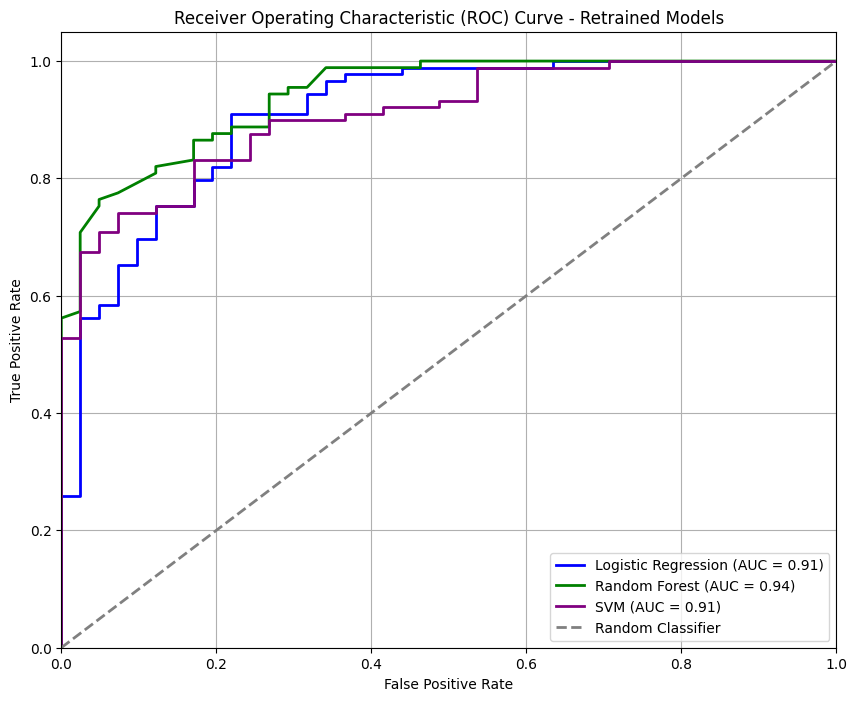

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# Logistic Regression
y_pred_proba_lr = model_real_combined.predict_proba(X_test_combined)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test_combined, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Random Forest
y_pred_proba_rf = model_rf_combined.predict_proba(X_test_combined)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test_combined, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# SVM (needs decision_function for probability-like scores)
# If SVM was trained with probability=True, use predict_proba
# Otherwise, use decision_function and scale it for roc_curve
# For simplicity, we assume SVC's default decision_function output can be used or `probability=True` was used.
# Given current training, `decision_function` is suitable for ROC for 'rbf' kernel.
y_score_svm = model_svm_combined.decision_function(X_test_combined)
fpr_svm, tpr_svm, _ = roc_curve(y_test_combined, y_score_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, color='purple', lw=2, label=f'SVM (AUC = {roc_auc_svm:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Retrained Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### **15. Test a Single Image Manually**

This section allows you to upload an individual image to test the performance of the retrained models directly. The image will be preprocessed in the same way as the training data (resized to 128x128, converted to grayscale, flattened, and normalized), and then passed to each model for prediction.

In [ ]:
from google.colab import files
import io

print("Upload a single image file (e.g., .jpg, .png) for testing:")
uploaded = files.upload()

Upload a single image file (e.g., .jpg, .png) for testing:


Saving no 3.jpg.jpeg to no 3.jpg (1).jpeg


User uploaded file "tumour.jpg.jpeg"

Preprocessed image shape: (1, 16384)


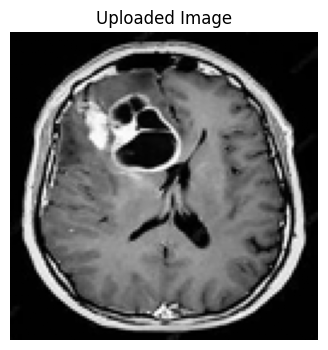


--- Predictions for 'tumour.jpg.jpeg' ---
Logistic Regression Prediction: Tumor
Random Forest Prediction: Tumor
SVM Prediction: Tumor
Logistic Regression Probability: No Tumor: 0.42, Tumor: 0.58
Random Forest Probability: No Tumor: 0.27, Tumor: 0.73


In [ ]:
if uploaded:
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')

        # Read image from bytes
        img_bytes = uploaded[fn]
        img = Image.open(io.BytesIO(img_bytes)).convert('L') # 'L' for grayscale
        img = img.resize(image_size)
        img_array = np.array(img).flatten() / 255.0 # Flatten and normalize

        X_single_test = np.array([img_array]) # Reshape for single sample prediction

        print(f"\nPreprocessed image shape: {X_single_test.shape}")

        plt.figure(figsize=(4, 4))
        plt.imshow(img_array.reshape(image_size), cmap='gray')
        plt.title("Uploaded Image")
        plt.axis('off')
        plt.show()

        # Make predictions with each retrained model
        pred_lr = model_real_combined.predict(X_single_test)[0]
        pred_rf = model_rf_combined.predict(X_single_test)[0]
        pred_svm = model_svm_combined.predict(X_single_test)[0]

        class_labels = {0: 'No Tumor', 1: 'Tumor'}

        print(f"\n--- Predictions for '{fn}' ---")
        print(f"Logistic Regression Prediction: {class_labels[pred_lr]}")
        print(f"Random Forest Prediction: {class_labels[pred_rf]}")
        print(f"SVM Prediction: {class_labels[pred_svm]}")

        # Optionally, predict probabilities (for LR and RF)
        if hasattr(model_real_combined, 'predict_proba'):
            proba_lr = model_real_combined.predict_proba(X_single_test)[0]
            print(f"Logistic Regression Probability: No Tumor: {proba_lr[0]:.2f}, Tumor: {proba_lr[1]:.2f}")
        if hasattr(model_rf_combined, 'predict_proba'):
            proba_rf = model_rf_combined.predict_proba(X_single_test)[0]
            print(f"Random Forest Probability: No Tumor: {proba_rf[0]:.2f}, Tumor: {proba_rf[1]:.2f}")

else:
    print("No file was uploaded.")

In [ ]:
print("Inspecting the contents of the current actual_data_root:")
for root, dirs, files in os.walk(actual_data_root):
    level = root.replace(actual_data_root, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    # Only print image files for brevity
    image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff'))]
    for f in image_files[:5]: # Print first 5 image files if any
        print(f'{subindent}{f}')
    if level > 1: # Limit depth of inspection for brevity
        break # Stop after inspecting two levels deep to avoid excessive output
    if not dirs and not image_files: # If a folder is empty, indicate it
        print(f'{subindent}(Empty or no image files found)')


Inspecting the contents of the current actual_data_root:
Testing/
    meningioma_tumor/
        image(14).jpg
        image(44).jpg
        image(42).jpg
        image(27).jpg
        image(39).jpg
    glioma_tumor/
        image(14).jpg
        image(44).jpg
        image(42).jpg
        image(27).jpg
        image(39).jpg
    no_tumor/
        image(14).jpg
        image(44).jpg
        image(42).jpg
        image(27).jpg
        image(39).jpg
    pituitary_tumor/
        image(44).jpg
        image(42).jpg
        image(27).jpg
        image(85).jpg
        image(68).jpg


In [ ]:
print("Inspecting the contents of the determined actual data root:")
for root, dirs, files in os.walk(actual_data_root):
    level = root.replace(actual_data_root, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff')):
            print(f'{subindent}{f}')
    if level == 0 and not dirs: # If actual_data_root itself contains files, print a few
        for f in files[:5]: # Print first 5 files if any
            print(f'{subindent}{f}')
    if level > 1: # Limit depth of inspection for brevity
        break

Inspecting the contents of the determined actual data root:
Testing/
    meningioma_tumor/
        image(14).jpg
        image(44).jpg
        image(42).jpg
        image(27).jpg
        image(39).jpg
        image(85).jpg
        image(68).jpg
        image(70).jpg
        image(45).jpg
        image(31).jpg
        image(80).jpg
        image(120).jpg
        image(84).jpg
        image(17).jpg
        image(76).jpg
        image(73).jpg
        image(46).jpg
        image(54).jpg
        image(53).jpg
        image(118).jpg
        image(113).jpg
        image(78).jpg
        image(20).jpg
        image(3).jpg
        image(29).jpg
        image(43).jpg
        image(37).jpg
        image(5).jpg
        image(127).jpg
        image(95).jpg
        image(89).jpg
        image(15).jpg
        image(50).jpg
        image(6).jpg
        image(28).jpg
        image(91).jpg
        image(8).jpg
        image(23).jpg
        image(4).jpg
        image(66).jpg
        image(126).jpg
       

#### **10.1. Evaluate Logistic Regression on External Test Data**

In [ ]:
if X_external_test.shape[0] > 0:
    y_pred_external_lr = model_real.predict(X_external_test)

    print("\nClassification Report (Logistic Regression - External Test Data):")
    print(classification_report(y_external_test, y_pred_external_lr))

    print("\nConfusion Matrix (Logistic Regression - External Test Data):")
    cm_external_lr = confusion_matrix(y_external_test, y_pred_external_lr)
    print(cm_external_lr)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_external_lr, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted No Tumor', 'Predicted Tumor'],
                yticklabels=['Actual No Tumor', 'Actual Tumor'])
    plt.title('Confusion Matrix (Logistic Regression - External Test Data)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
else:
    print("No external test data loaded for Logistic Regression evaluation.")
    y_pred_external_lr = np.array([]) # Define as empty array to prevent NameError in subsequent cells

No external test data loaded for Logistic Regression evaluation.


#### **10.2. Evaluate Random Forest on External Test Data**

In [ ]:
if X_external_test.shape[0] > 0:
    y_pred_external_rf = model_rf.predict(X_external_test)

    print("\nClassification Report (Random Forest - External Test Data):")
    print(classification_report(y_external_test, y_pred_external_rf))

    print("\nConfusion Matrix (Random Forest - External Test Data):")
    cm_external_rf = confusion_matrix(y_external_test, y_pred_external_rf)
    print(cm_external_rf)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_external_rf, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Predicted No Tumor', 'Predicted Tumor'],
                yticklabels=['Actual No Tumor', 'Actual Tumor'])
    plt.title('Confusion Matrix (Random Forest - External Test Data)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
else:
    print("No external test data loaded for Random Forest evaluation.")
    y_pred_external_rf = np.array([]) # Define as empty array to prevent NameError in subsequent cells

No external test data loaded for Random Forest evaluation.


#### **10.3. Evaluate SVM on External Test Data**

In [ ]:
if X_external_test.shape[0] > 0:
    y_pred_external_svm = model_svm.predict(X_external_test)

    print("\nClassification Report (SVM - External Test Data):")
    print(classification_report(y_external_test, y_pred_external_svm))

    print("\nConfusion Matrix (SVM - External Test Data):")
    cm_external_svm = confusion_matrix(y_external_test, y_pred_external_svm)
    print(cm_external_svm)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_external_svm, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Predicted No Tumor', 'Predicted Tumor'],
                yticklabels=['Actual No Tumor', 'Actual Tumor'])
    plt.title('Confusion Matrix (SVM - External Test Data)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
else:
    print("No external test data loaded for SVM evaluation.")
    y_pred_external_svm = np.array([]) # Define as empty array to prevent NameError in subsequent cells

No external test data loaded for SVM evaluation.


#### **10.4. Compare Model Accuracies on External Test Data**

In [ ]:
from sklearn.metrics import accuracy_score

if X_external_test.shape[0] > 0:
    accuracy_external_lr = accuracy_score(y_external_test, y_pred_external_lr)
    accuracy_external_rf = accuracy_score(y_external_test, y_pred_external_rf)
    accuracy_external_svm = accuracy_score(y_external_test, y_pred_external_svm)

    model_accuracies_external = pd.DataFrame({
        'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
        'Accuracy': [accuracy_external_lr, accuracy_external_rf, accuracy_external_svm]
    })

    plt.figure(figsize=(8, 6))
    sns.barplot(x='Model', y='Accuracy', data=model_accuracies_external, palette='viridis')
    plt.title('Comparison of Model Accuracies on External Test Data')
    plt.ylim(0, 1) # Accuracy is between 0 and 1
    plt.ylabel('Accuracy Score')
    plt.xlabel('Classifier Model')

    for index, row in model_accuracies_external.iterrows():
        plt.text(row.name, row.Accuracy + 0.02, f'{row.Accuracy:.2f}', color='black', ha='center')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
else:
    print("Cannot compare model accuracies as no external test data was loaded.")

Cannot compare model accuracies as no external test data was loaded.
